# Build Schwinger Hamiltonian

In [112]:
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Acmatix\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [113]:
import numpy as np
from scipy.linalg import ishermitian
import matplotlib.pyplot as plt


In [114]:
def PauliX(pos, num_qubits):
    m = pos - 1
    # Define single-qubit Pauli-X and Identity
    X = np.array([[0, 1], 
                  [1, 0]])
    I = np.identity(2)
    
    operator = 1
    for i in range(num_qubits):
        # Apply X at the nth position (0-indexed), and I everywhere else
        current_gate = X if i == m else I
        operator = np.kron(operator, current_gate) if i > 0 else current_gate
        
    return operator

In [115]:
def PauliY(pos, num_qubits):
    m = pos - 1
    # Define single-qubit Pauli-Y and Identity
    Y = np.array([[0, -1j], 
                  [1j, 0]])
    I = np.identity(2)
    
    operator = 1
    for i in range(num_qubits):
        # Apply Y at the nth position (0-indexed), and I everywhere else
        current_gate = Y if i == m else I
        operator = np.kron(operator, current_gate) if i > 0 else current_gate
        
    return operator

In [116]:
def PauliZ(pos, num_qubits):
    m = pos - 1
    # Define single-qubit Pauli-Z and Identity
    Z = np.array([[1, 0], 
                  [0, -1]])
    I = np.identity(2)
    
    operator = 1
    for i in range(num_qubits):
        # Apply Z at the nth position (0-indexed), and I everywhere else
        current_gate = Z if i == m else I
        operator = np.kron(operator, current_gate) if i > 0 else current_gate
        
    return operator

In [117]:
def L_n(n, N):
    """Construct the L_n operator for the Schwinger model.
    
    Parameters
    ----------
    n : int
        The position of the L_n operator (1-indexed).
    N : int
        The total number of qubits in the system.
    
    Returns
    ------- 
    L_n : np.ndarray, shape (2**N, 2**N), complex
        The L_n operator as a matrix.
    """
    temp = H = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(1, n+1):
        temp += (np.identity(2**N) * (-1)**i + PauliZ(i, N) ) / 2

    return temp


In [118]:
def build_hamiltonian(N, a = 1, g = 1, m = 0.25, theta=0.0, boundary="open"):
    """
    Build the lattice Schwinger model Hamiltonian (Ikeda eq. 3) as a dense matrix.

    Parameters
    ----------
    N : int
        Number of qubits in the system.


    theta : float, optional
        Vacuum angle (default is 0.0).

    boundary : str, optional
        Boundary condition, either "open" or "periodic" (default is "open"). 

    Returns
    -------
    H : np.ndarray, shape (2**N, 2**N), complex
        Hermitian Hamiltonian matrix.
    """
    H = np.zeros((2**N, 2**N), dtype=complex)
    for i in range(1, N):
        H += (PauliX(i, N) @ PauliX(i+1, N) + PauliY(i, N) @ PauliY(i+1, N))/ (4*a)
    
    for i in range(1, N+1):
        H += m * (-1)**i * PauliZ(i, N) / 2
    
    for i in range(1, N):
        H += a * g**2 * L_n(i, N) @ L_n(i, N) / 2
    
    if ishermitian(H):
        #print("Hamiltonian is Hermitian.")
        return H
    


In [119]:
H = build_hamiltonian(4, a=1, g=1, m=0.25, theta=0.0, boundary="open")

# Diagonalize Hamiltonian

In [120]:
eigenvalues, P = np.linalg.eig(H)

D = np.diag(eigenvalues)

print("Eigenvectors (P):\n", P)
print("\nDiagonal Matrix (D):\n", D)

Eigenvectors (P):
 [[ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  0.00000000e+00+0.j  1.00000000e+00+0.j
   0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j  1.29752780e-01+0.j  5.83288176e-01+0.j
  -3.60015035e-01+0.j  7.16469325e-01+0.j  9.39512450e-17-0.j
  -1.76350768e-17+0.j -4.66007259e-16+0.j -6.62174433e-17+0.j
  -1.12694853e-16+0.j -6.14845036e-17+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
   0.00000000e+00+0.j -3.60015035e-01+0.j  7.16469325e-01+0.j
  -1.29752780e-01+0.j -5.83288176e-01+0.j -7.52076289e-17+0.j
  -7.39003667e-17+0.j -5.75035140e-16+0.j -1.30962288e-16+0.j
  -1.16227186e-17+0.j  2.98308425e-17-0.j  0.00000000e+00+0.j
   0.

In [121]:
# Find the ground state (lowest eigenvalue)
ground_state_idx = np.argmin(eigenvalues)
ground_state_energy = eigenvalues[ground_state_idx]
ground_state_vector = P[:, ground_state_idx]

print("Ground State Energy:", ground_state_energy)
print("Ground State Eigenvector:\n", ground_state_vector)

Ground State Energy: (-1.0377388671799863+0j)
Ground State Eigenvector:
 [ 0.00000000e+00+0.j  9.39512450e-17-0.j -7.52076289e-17+0.j
 -2.73654156e-01+0.j  1.77096044e-16-0.j  8.41617264e-01+0.j
 -3.15743236e-01+0.j  0.00000000e+00+0.j -5.45558411e-17+0.j
 -3.15743236e-01+0.j  1.29444028e-01-0.j  0.00000000e+00+0.j
 -2.55038117e-02+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j
  0.00000000e+00+0.j]


In [122]:
def chiral_condensate_op(N):
    op = np.zeros((2**N, 2**N), dtype=complex)
    for n in range(1, N+1):
        op += (-1)**n * PauliZ(n, N)
    return op / N

In [123]:
chiral_condensate_operator = chiral_condensate_op(4)

expectation_value = np.vdot(ground_state_vector, chiral_condensate_operator @ ground_state_vector)

In [124]:
print("Expectation value of the chiral condensate operator in the ground state:", expectation_value)

Expectation value of the chiral condensate operator in the ground state: (-0.6915638630067225+0j)


# Build QCL Dataset

In [125]:
def get_chiral_based_on_m(N, m):
    H = build_hamiltonian(N, a=1, g=1, m=m, theta=0.0, boundary="open")
    eigenvalues, P = np.linalg.eig(H)
    ground_state_idx = np.argmin(eigenvalues)
    ground_state_vector = P[:, ground_state_idx]
    
    chiral_condensate_operator = chiral_condensate_op(N)
    expectation_value = np.vdot(ground_state_vector, chiral_condensate_operator @ ground_state_vector)
    
    return np.real(expectation_value)

In [126]:
def build_dataset(N, m_max, num_points):
    data = []
    for m in np.linspace(0.1, m_max, num_points):
        chiral_value = get_chiral_based_on_m(N, m)
        data.append((m, chiral_value))
    return data

In [127]:
data = build_dataset(4, 2.0, 31)

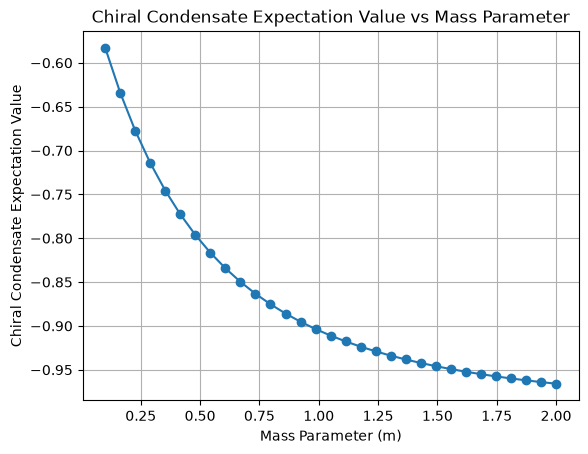

In [128]:
x_values, y_values = zip(*data)

plt.plot(x_values, y_values, marker='o', linestyle='-')

# Add labels and a title
plt.xlabel('Mass Parameter (m)')
plt.ylabel('Chiral Condensate Expectation Value')
plt.title('Chiral Condensate Expectation Value vs Mass Parameter')

# Display the plot
plt.grid(True)
plt.show()


# Build QCL Circuit

In [129]:
!pip install pennylane

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.1.3 requires numpy<2,>=1.23.2; python_version == "3.11", but you have numpy 2.4.6 which is incompatible.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.6 which is incompatible.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Acmatix\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [130]:
import pennylane as qml
from pennylane import numpy as pnp   # PennyLane's autodiff-aware numpy wrapper

In [131]:
n_model_qubits = 3
n_layers = 4

dev = qml.device("default.qubit", wires=n_model_qubits)

In [132]:
def encode(m):
    angle = pnp.pi * m / 2.0          # m_max = 2.0  -> maps [0.1, 2.0] to ~[0.16, pi]
    features = [angle] * n_model_qubits
    qml.AngleEmbedding(features=features, wires=range(n_model_qubits), rotation="Y")


In [133]:
def ansatz(theta):
    qml.BasicEntanglerLayers(weights=theta, wires=range(n_model_qubits), rotation=qml.RY)

In [134]:
@qml.qnode(dev)
def circuit(m, theta):
    """Returns <Z_0>, a single real number in [-1, 1]."""
    encode(m)
    ansatz(theta)
    return qml.expval(qml.PauliZ(0))

In [143]:
def predict(m, theta, w, b):
    v = circuit(m, theta)
    return w*v + b

In [144]:
def mse_loss(theta, w, b, m_train, y_train):
    y = pnp.array(y_train)
    preds = pnp.stack([predict(m, theta, w, b) for m in m_train])
    return pnp.mean((preds - y) ** 2)

In [146]:
def train(m_train, y_train, steps=200, lr=0.05, seed=0):
    rng = np.random.default_rng(seed)
    theta_shape = qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_model_qubits)

    theta = pnp.array(rng.random(theta_shape), requires_grad=True)
    w = pnp.array(0.2, requires_grad=True)
    b = pnp.array(-0.78, requires_grad=True)

    opt = qml.AdamOptimizer(stepsize=lr)

    for step in range(steps):
        (theta, w, b), loss = opt.step_and_cost(
            lambda t, ww, bb: mse_loss(t, ww, bb, m_train, y_train),
            theta, w, b
        )
        if step % 20 == 0:
            print(f"step {step:4d}   loss {loss:.6f}")

    return theta, w, b


# Evaluation

In [138]:
!pip install scikit-learn

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pennylane 0.45.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\Acmatix\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [139]:
from sklearn.model_selection import train_test_split


In [ ]:
training_data, testing_data = train_test_split(data, test_size=0.2, random_state=42)

#params = train(m_train=[m for m, _ in training_data], y_train=[y for _, y in training_data], steps=200, lr=0.05, seed=0)

step    0   loss 0.009729
step   20   loss 0.000873
step   40   loss 0.000310
step   60   loss 0.000174
step   80   loss 0.000160
step  100   loss 0.000158
step  120   loss 0.000157
step  140   loss 0.000156
step  160   loss 0.000154
step  180   loss 0.000154


In [150]:
def evaluate(theta, w, b, testing_data, training_data=None):
    """Predict on held-out test points, plot exact vs predicted, report test MSE."""
    # --- pull out test inputs/targets ---
    m_test = [m for m, _ in testing_data]
    y_test = np.array([np.real(y) for _, y in testing_data])   # condensate is real; drop tiny imag part

    # --- model predictions on the test masses ---
    preds = np.array([float(np.real(predict(m, theta, w, b))) for m in m_test])

    # --- test MSE ---
    test_mse = np.mean((preds - y_test) ** 2)
    print(f"Test MSE: {test_mse:.6f}")

    # --- plot: exact curve (all data, sorted) as a line, model predictions as points ---
    all_sorted = sorted(data, key=lambda p: p[0])
    m_all = [m for m, _ in all_sorted]
    y_all = [np.real(y) for _, y in all_sorted]

    plt.figure(figsize=(7, 5))
    plt.plot(m_all, y_all, color="tab:blue", label="Exact (diagonalization)")
    plt.scatter(m_test, preds, color="tab:red", zorder=5, label="QCL prediction (test)")
    if training_data is not None:
        m_tr = [m for m, _ in training_data]
        p_tr = [float(np.real(predict(m, theta, w, b))) for m in m_tr]
        plt.scatter(m_tr, p_tr, color="tab:green", marker="x", alpha=0.6, label="QCL prediction (train)")
    plt.xlabel("mass m")
    plt.ylabel("chiral condensate")
    plt.title(f"QCL vs exact  (test MSE = {test_mse:.4f})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return test_mse

step    0   loss 0.009729
step   20   loss 0.000873
step   40   loss 0.000310
step   60   loss 0.000174
step   80   loss 0.000160
step  100   loss 0.000158
step  120   loss 0.000157
step  140   loss 0.000156
step  160   loss 0.000154
step  180   loss 0.000154
Test MSE: 0.000065


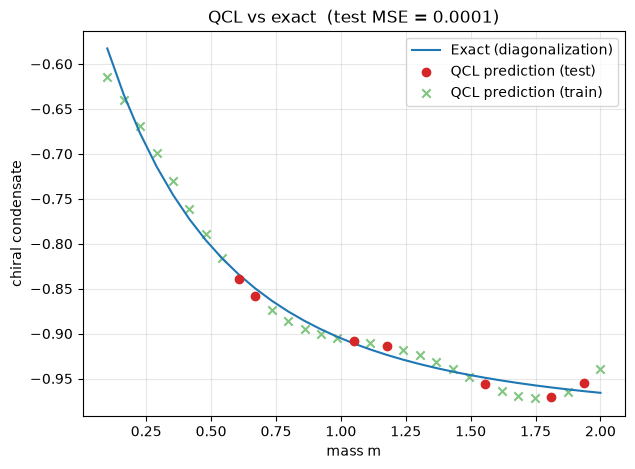

6.483763703374439e-05

In [152]:
theta, w, b = train(m_train=[m for m, _ in training_data],
                    y_train=[y for _, y in training_data],
                    steps=200, lr=0.05, seed=0)

evaluate(theta, w, b, testing_data, training_data)
